In [ ]:
# Capture trained model outputs for comparison
trained_outputs = []
for p in baseline_prompts:
    inputs = tokenizer.apply_chat_template(
        [{"role":"system","content":SYSTEM_PROMPT},
         {"role":"user","content":p}],
        tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=200, temperature=0.7, do_sample=True)
    text = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    trained_outputs.append(text)
    print(f"TRAINED {p[:30]}...")
    print(text[:200])
    print("---")

# Compare side by side
print("\n" + "="*50)
print("BEFORE vs AFTER TRAINING COMPARISON")
print("="*50)
for i, (b, t, p) in enumerate(zip(baseline_outputs, trained_outputs, baseline_prompts)):
    print(f"\n[Personality: {['brave', 'cautious', 'explorer'][i]}]")
    print(f"Prompt: {p[:50]}")
    print(f"\nBEFORE:\n{b[:200]}")
    print(f"\nAFTER:\n{t[:200]}")
    print("-" * 50)

In [ ]:
!pip install unsloth trl openenv-core requests matplotlib Pillow

In [48]:
ENV_URL = "https://pranavgadodia-levelforge-env.hf.space"  # placeholder
MODEL_NAME = "unsloth/Qwen2.5-0.5B-Instruct"
MAX_STEPS = 200

In [49]:
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    MODEL_NAME, max_seq_length=1024, load_in_4bit=True,
    fast_inference=False, max_lora_rank=32, gpu_memory_utilization=0.6)
model = FastLanguageModel.get_peft_model(
    model, r=32, lora_alpha=32,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    use_gradient_checkpointing="unsloth", random_state=3407)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [50]:
SYSTEM_PROMPT = """You are a game level designer for a 2D platformer.
You are given an 8x16 grid and must place tiles to create a fun level.
Tiles: . (empty) # (wall) ^ (spike) $ (coin) E (enemy) P (player) G (goal)
Always wrap your thinking in <think>...</think> tags first.
Then output your edits as JSON: {"edits": [{"row": N, "col": N, "tile": "X"}], "declare_done": false}
Design for the given player personality: brave/cautious/explorer"""

In [ ]:
import torch

# Capture baseline outputs before training
baseline_prompts = [
    "Design a first_steps level for a brave player. Target path length: 16.",
    "Design a first_steps level for a cautious player. Target path length: 16.", 
    "Design a first_steps level for an explorer player. Target path length: 16.",
]

baseline_outputs = []
for p in baseline_prompts:
    inputs = tokenizer.apply_chat_template(
        [{"role":"system","content":SYSTEM_PROMPT},
         {"role":"user","content":p}],
        tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=200, temperature=0.7, do_sample=True)
    text = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    baseline_outputs.append(text)
    print(f"BASELINE {p[:30]}...")
    print(text[:200])
    print("---")

print("✅ Baseline captured. Starting training...")

In [51]:
import requests, json

# Global session to keep connection alive
session = requests.Session()

def call_env_reward(prompts, completions, **kwargs):
    rewards = []

    # Extract task/personality from the prompt text itself
    for i, (prompt, completion) in enumerate(zip(prompts, completions)):
        try:
            # Parse task and personality from the user message
            user_msg = ""
            for msg in prompt:
                if msg["role"] == "user":
                    user_msg = msg["content"]
                    break

            # Extract from prompt text
            task = "first_steps"
            personality = "brave"
            if "gap_jumper" in user_msg:
                task = "gap_jumper"
            elif "symmetric_shrine" in user_msg:
                task = "symmetric_shrine"
            if "cautious" in user_msg:
                personality = "cautious"
            elif "explorer" in user_msg:
                personality = "explorer"

            # Wake up + reset
            session.get(f"{ENV_URL}/health", timeout=20)
            session.post(f"{ENV_URL}/reset",
                json={"task_name": task, "personality": personality},
                timeout=20)

            # Step
            text = completion[0]["content"]
            resp = session.post(f"{ENV_URL}/step",
                json={"reasoning": text[:400], "edits": [], "declare_done": False},
                timeout=20)

            data = resp.json()
            total = float(data["reward"]["total"])
            rewards.append(max(1e-6, min(1.0 - 1e-6, total)))

        except Exception as e:
            print(f"env_reward error {i}: {e}")
            rewards.append(1e-6)

    return rewards

def format_reward(prompts, completions, **kwargs):
    scores = []
    for c in completions:
        text = c[0]["content"]
        has_open = "<think>" in text
        has_close = "</think>" in text
        raw = (0.499 if has_open else 0) + (0.499 if has_close else 0)
        scores.append(max(1e-6, min(1.0 - 1e-6, raw)))
    return scores

In [52]:
from datasets import Dataset

# Build scenarios directly in Colab — no API call needed
SCENARIOS = [
    # first_steps — easy task
    {"task_name": "first_steps", "personality": "brave",    "target_path_len": 16, "target_coin_count": 3},
    {"task_name": "first_steps", "personality": "cautious", "target_path_len": 16, "target_coin_count": 3},
    {"task_name": "first_steps", "personality": "explorer", "target_path_len": 16, "target_coin_count": 3},
    # gap_jumper — medium task
    {"task_name": "gap_jumper",  "personality": "brave",    "target_path_len": 22, "target_coin_count": 4},
    {"task_name": "gap_jumper",  "personality": "cautious", "target_path_len": 22, "target_coin_count": 4},
    {"task_name": "gap_jumper",  "personality": "explorer", "target_path_len": 22, "target_coin_count": 4},
    # symmetric_shrine — hard task
    {"task_name": "symmetric_shrine", "personality": "brave",    "target_path_len": 30, "target_coin_count": 6},
    {"task_name": "symmetric_shrine", "personality": "cautious", "target_path_len": 30, "target_coin_count": 6},
    {"task_name": "symmetric_shrine", "personality": "explorer", "target_path_len": 30, "target_coin_count": 6},
]

PERSONALITY_HINTS = {
    "brave":    "Place many spikes (^) and enemies (E) for a dangerous, exciting level. Narrow paths are good.",
    "cautious": "Keep paths wide and open. Use few spikes. Make it safe and comfortable to navigate.",
    "explorer": "Create multiple branching paths with hidden coins ($) in unexpected places.",
}

data = []
for s in (SCENARIOS * 23)[:200]:  # repeat to get 200 samples
    hint = PERSONALITY_HINTS[s["personality"]]
    user_msg = (
        f"Task: {s['task_name']} | Personality: {s['personality']} | "
        f"Target path length: {s['target_path_len']} | Target coins: {s['target_coin_count']}\n"
        f"Player hint: {hint}\n"
        f"Design the level now. Use JSON edits format."
    )
    data.append({
        "prompt": [
            {"role": "system",  "content": SYSTEM_PROMPT},
            {"role": "user",    "content": user_msg},
        ],
        # Store metadata for reward function to use
        "task_name":   s["task_name"],
        "personality": s["personality"],
    })

dataset = Dataset.from_list(data)
print(f"✅ Dataset size: {len(dataset)}")
print(f"✅ Tasks: {set(d['task_name'] for d in data)}")
print(f"✅ Personalities: {set(d['personality'] for d in data)}")
print(f"✅ First prompt preview: {data[0]['prompt'][1]['content'][:100]}")

✅ Dataset size: 200
✅ Tasks: {'first_steps', 'symmetric_shrine', 'gap_jumper'}
✅ Personalities: {'cautious', 'brave', 'explorer'}
✅ First prompt preview: Task: first_steps | Personality: brave | Target path length: 16 | Target coins: 3
Player hint: Place


In [ ]:
from trl import GRPOConfig, GRPOTrainer

args = GRPOConfig(
    learning_rate=5e-6,
    optim="paged_adamw_8bit",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    num_generations=4,
    max_prompt_length=256,
    max_completion_length=768,
    max_steps=MAX_STEPS,
    save_steps=50,
    beta=0.04,
    loss_type="dr_grpo",
    mask_truncated_completions=True,
    report_to="none",
    output_dir="levelforge_out"
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[format_reward, call_env_reward],
    args=args,
    train_dataset=dataset
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 17,596,416 of 511,629,184 (3.44% trained)
Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / format_reward / mean,rewards / format_reward / std,rewards / call_env_reward / mean,rewards / call_env_reward / std
1,0.000000,0.768547,0.000000,325.750000,123.000000,768.000000,0.250000,178.333344,123.000000,252.000000,0.000000,0.000001,0.000000,0.768546,0.000000
2,0.000000,0.663389,0.000000,295.750000,11.000000,768.000000,0.250000,138.333344,11.000000,353.000000,0.000000,0.000001,0.000000,0.663388,0.000000
3,0.000000,0.841580,0.000000,310.500000,47.000000,533.000000,0.000000,310.500000,47.000000,533.000000,0.000000,0.000001,0.000000,0.841579,0.000000
4,0.000000,0.841580,0.000000,115.250000,11.000000,381.000000,0.000000,115.250000,11.000000,381.000000,0.000000,0.000001,0.000000,0.841579,0.000000
5,0.000000,0.841580,0.000000,393.500000,79.000000,768.000000,0.250000,268.666687,79.000000,519.000000,0.000000,0.000001,0.000000,0.841579,0.000000
6,0.000000,0.946738,0.000000,527.750000,139.000000,768.000000,0.500000,287.500000,139.000000,436.000000,0.000000,0.000001,0.000000,0.946737,0.000000
7,0.000000,0.946738,0.000000,325.250000,10.000000,768.000000,0.250000,177.666672,10.000000,430.000000,0.000000,0.000001,0.000000,0.946737,0.000000


Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=768) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Total log entries: 51
Sample entry: {'loss': 0.0, 'grad_norm': 0.0, 'learning_rate': 0.0, 'num_tokens': 2055.0, 'completions/mean_length': 325.75, 'completions/min_length': 123.0, 'completions/max_length': 768.0, 'completions/clipped_ratio': 0.25, 'completions/mean_terminated_length': 178.33334350585938, 'completions/min_terminated_length': 123.0, 'completions/max_terminated_length': 252.0, 'rewards/format_reward/mean': 9.999999974752427e-07, 'rewards/format_reward/std': 0.0, 'rewards/call_env_reward/mean': 9.999999974752427e-07, 'rewards/call_env_reward/std': 0.0, 'reward': 1.9999999949504854e-06, 'reward_std': 0.0, 'frac_reward_zero_std': 1.0, 'completion_length': 325.75, 'kl': 0.0, 'clip_ratio/low_mean': 0.0, 'clip_ratio/low_min': 0.0, 'clip_ratio/high_mean': 0.0, 'clip_ratio/high_max': 0.0, 'clip_ratio/region_mean': 0.0, 'epoch': 0.005, 'step': 1}
Steps with reward data: 50
Reward values: [1.9999999949504854e-06, 1.9999999949504854e-06, 1.9999999949504854e-06, 1.9999999949504854e-0

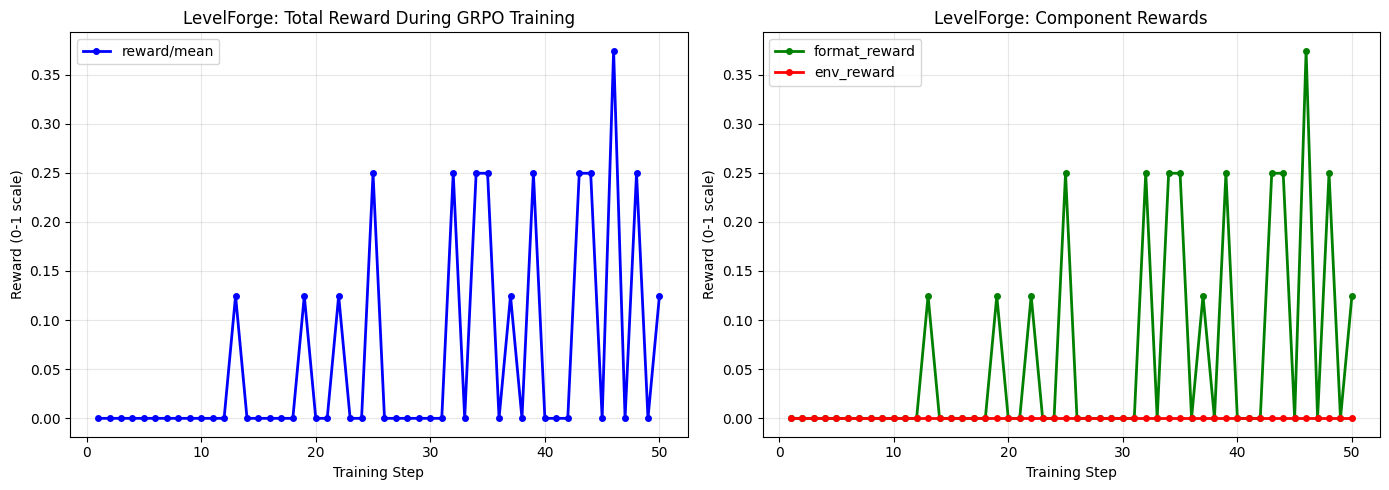

✅ Saved reward_curve.png


In [31]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
print(f"Total log entries: {len(log_history)}")
print(f"Sample entry: {log_history[0] if log_history else 'empty'}")

# Extract reward values
steps, rewards, format_rewards, env_rewards = [], [], [], []
for log in log_history:
    if "reward" in log:
        steps.append(log.get("step", len(steps)))
        rewards.append(log.get("reward", 0))
        format_rewards.append(log.get("rewards/format_reward/mean", 0))
        env_rewards.append(log.get("rewards/call_env_reward/mean", 0))

print(f"Steps with reward data: {len(steps)}")
print(f"Reward values: {rewards[:5]}")

if steps:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1 - total reward
    axes[0].plot(steps, rewards, 'b-o', linewidth=2, markersize=4, label="reward/mean")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Reward (0-1 scale)")
    axes[0].set_title("LevelForge: Total Reward During GRPO Training")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2 - component rewards
    axes[1].plot(steps, format_rewards, 'g-o', linewidth=2, markersize=4, label="format_reward")
    axes[1].plot(steps, env_rewards, 'r-o', linewidth=2, markersize=4, label="env_reward")
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Reward (0-1 scale)")
    axes[1].set_title("LevelForge: Component Rewards")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("reward_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved reward_curve.png")
else:
    print("❌ No reward data in log_history")
    print("All log keys:", [list(l.keys()) for l in log_history[:3]])